# 风速降尺度算法验证

本 Notebook 读取 `test_data/wind_calculations_data/` 官方投影坐标样例，经预处理写出 `cli_input/` 后运行迁移算法，并与 KGO、原 IMPROVER 结果对比。

**关于原方法输入约束**：上游 IMPROVER `RoughnessCorrection` 要求空间坐标名为 `projection_x_coordinate` / `projection_y_coordinate` 且单位为米；插件内部不做投影转经纬或重网格。因此本 notebook 仅做**维名重命名**（投影维 → `lat/lon`，数值仍为米制投影坐标），不采用「经纬重网格」第二套验证方案；KGO 与 `original_algorithm_result.nc` 直接读取数据根目录下的官方投影 nc。

对比图包括：原始输入、修改后算法、KGO、原算法结果。

## 环境准备

In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PACKAGE_ROOT = Path.cwd().resolve().parents[0]
PROJECT_ROOT = PACKAGE_ROOT.parent
DATA_DIR = (PACKAGE_ROOT / "test_data/wind_calculations_data").resolve()
CLI_INPUT_DIR = DATA_DIR / "cli_input"
MODEL_RESOLUTION = 1500.0

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from orographic_wind_downscaling.cli.dsc_wind_downscaling import process as cli_process
from orographic_wind_downscaling.src.wind_downscaling import RoughnessCorrection

print(f"包根目录: {PACKAGE_ROOT}")
print(f"数据目录: {DATA_DIR}")
print(f"模式分辨率: {MODEL_RESOLUTION} m")

d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


包根目录: D:\workspace\improver\wind_calculations
数据目录: D:\workspace\improver\wind_calculations\test_data\wind_calculations_data
模式分辨率: 1500.0 m


## 数据预处理

读官方投影 nc → 将 `projection_*` 重命名为 `lat/lon` → 构造六维 meb 网格 → 写出 `cli_input/`。

In [2]:
import json

INPUT_JOBS = [
    ("input.nc", "wind_speed"),
    ("a_over_s.nc", "silhouette_roughness"),
    ("sigma.nc", "standard_deviation_of_height_in_grid_cell"),
    ("highres_orog.nc", "surface_altitude"),
    ("standard_orog.nc", "surface_altitude"),
    ("veg.nc", "vegetative_roughness_length"),
]


def load_primary_dataarray(nc_path: Path, var_name: str) -> xr.DataArray:
    """读取 netCDF 主变量，并写入 grid_mapping_attrs。"""
    ds = xr.open_dataset(nc_path, decode_timedelta=False)
    try:
        if var_name not in ds.data_vars:
            raise ValueError(f"变量 {var_name} 不存在: {nc_path}")
        data = ds[var_name].load()
        grid_mapping_name = data.attrs.get("grid_mapping")
        if not isinstance(grid_mapping_name, str) or grid_mapping_name not in ds.variables:
            for other_name in ds.data_vars:
                cand = ds[other_name].attrs.get("grid_mapping")
                if isinstance(cand, str) and cand in ds.variables:
                    grid_mapping_name = cand
                    break
        if isinstance(grid_mapping_name, str) and grid_mapping_name in ds.variables:
            mapping_attrs_raw = dict(ds[grid_mapping_name].attrs)
            mapping_attrs_json_ready = {}
            for key, value in mapping_attrs_raw.items():
                if isinstance(value, np.ndarray):
                    mapping_attrs_json_ready[key] = value.tolist()
                elif isinstance(value, np.generic):
                    mapping_attrs_json_ready[key] = value.item()
                else:
                    mapping_attrs_json_ready[key] = value
            data.attrs["grid_mapping_attrs"] = json.dumps(
                mapping_attrs_json_ready, ensure_ascii=False
            )
        return data
    finally:
        ds.close()


def _extract_projected_spatial(da: xr.DataArray) -> xr.DataArray:
    """提取投影空间场；保留 level，将 height/投影维重命名为 level/lat/lon。"""
    arr = da
    rename_map = {}
    if "height" in arr.dims:
        rename_map["height"] = "level"
    if "projection_y_coordinate" in arr.dims:
        rename_map["projection_y_coordinate"] = "lat"
    if "projection_x_coordinate" in arr.dims:
        rename_map["projection_x_coordinate"] = "lon"
    if rename_map:
        arr = arr.rename(rename_map)
    keep_dims = ("level", "lat", "lon")
    for dim in list(arr.dims):
        if dim not in keep_dims:
            arr = arr.isel({dim: 0}, drop=True)
    expected_order = [d for d in keep_dims if d in arr.dims]
    return arr.transpose(*expected_order)


def _build_meb6d_from_spatial(spatial: xr.DataArray, *, name: str) -> xr.DataArray:
    units = str(spatial.attrs.get("units", "1"))
    if "level" in spatial.dims:
        level_values = spatial.coords["level"].values.astype(np.float32)
        values = spatial.values[np.newaxis, :, np.newaxis, np.newaxis, :, :].astype(np.float32)
    else:
        level_values = np.array([0.0], dtype=np.float32)
        values = spatial.values[np.newaxis, np.newaxis, np.newaxis, np.newaxis, :, :].astype(np.float32)
    attrs = {
        "units": units,
        "model": None,
        "dtime_units": "hour",
        "level_type": "height",
        "time_type": "UT",
        "time_bounds": [0, 0],
    }
    grid_mapping_attrs = spatial.attrs.get("grid_mapping_attrs")
    if isinstance(grid_mapping_attrs, str) and grid_mapping_attrs.strip():
        attrs["grid_mapping_attrs"] = grid_mapping_attrs
    return xr.DataArray(
        values,
        dims=("member", "level", "time", "dtime", "lat", "lon"),
        coords={
            "member": np.array(["data0"], dtype=object),
            "level": level_values,
            "time": np.array([np.datetime64("1970-01-01T00:00:00")], dtype="datetime64[ns]"),
            "dtime": np.array([0], dtype=np.int32),
            "lat": spatial.coords["lat"].copy(deep=True),
            "lon": spatial.coords["lon"].copy(deep=True),
        },
        attrs=attrs,
        name=name,
    )


def build_meb6d_from_projected(nc_path: Path, var_name: str) -> xr.DataArray:
    spatial = _extract_projected_spatial(load_primary_dataarray(nc_path, var_name))
    return _build_meb6d_from_spatial(spatial, name=var_name)


def save_meb6d_to_nc(data: xr.DataArray, dst_path: Path) -> None:
    normalized = data.copy(deep=True)
    normalized.attrs = {k: ("" if v is None else v) for k, v in dict(normalized.attrs).items()}
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    normalized.to_dataset(name=normalized.name).to_netcdf(dst_path)
    print(f"写出: {dst_path}")


cli_inputs = {
    filename: build_meb6d_from_projected(DATA_DIR / filename, var_name)
    for filename, var_name in INPUT_JOBS
}
for filename, data in cli_inputs.items():
    save_meb6d_to_nc(data, CLI_INPUT_DIR / filename)

wind_speed_da = cli_inputs["input.nc"]
print("预处理输入:", wind_speed_da.dims, wind_speed_da.shape)

写出: D:\workspace\improver\wind_calculations\test_data\wind_calculations_data\cli_input\input.nc
写出: D:\workspace\improver\wind_calculations\test_data\wind_calculations_data\cli_input\a_over_s.nc
写出: D:\workspace\improver\wind_calculations\test_data\wind_calculations_data\cli_input\sigma.nc
写出: D:\workspace\improver\wind_calculations\test_data\wind_calculations_data\cli_input\highres_orog.nc
写出: D:\workspace\improver\wind_calculations\test_data\wind_calculations_data\cli_input\standard_orog.nc
写出: D:\workspace\improver\wind_calculations\test_data\wind_calculations_data\cli_input\veg.nc
预处理输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 9, 1, 1, 101, 101)


## 辅助输入场

展示除风速外进入 `RoughnessCorrection` 的 ancillary 场（二维空间分布）。

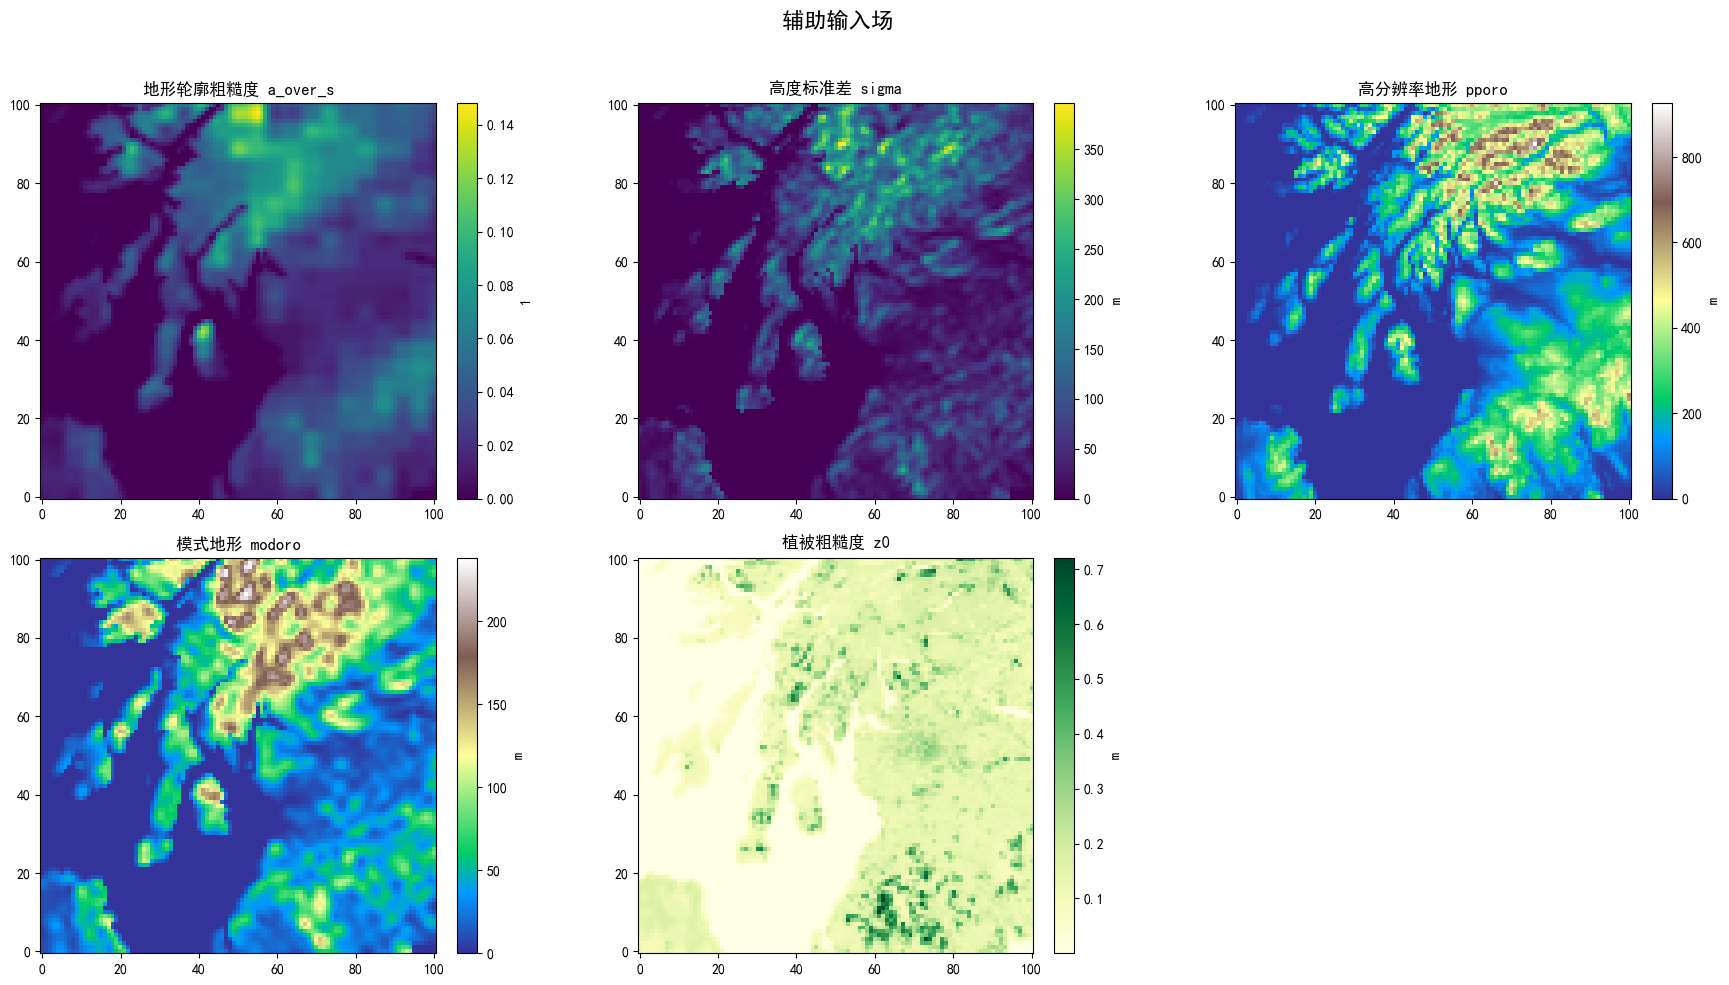

In [3]:
def to_display_2d(da: xr.DataArray) -> np.ndarray:
    """将六维 meb 场 squeeze 为二维 lat/lon 数组用于绘图。"""
    arr = np.squeeze(np.asarray(da.values, dtype=np.float64))
    if arr.ndim != 2:
        raise ValueError(f"期望二维空间场，当前 shape={arr.shape}")
    return arr


aux_fields = [
    ("地形轮廓粗糙度 a_over_s", cli_inputs["a_over_s.nc"], "viridis", "1"),
    ("高度标准差 sigma", cli_inputs["sigma.nc"], "viridis", "m"),
    ("高分辨率地形 pporo", cli_inputs["highres_orog.nc"], "terrain", "m"),
    ("模式地形 modoro", cli_inputs["standard_orog.nc"], "terrain", "m"),
    ("植被粗糙度 z0", cli_inputs["veg.nc"], "YlGn", "m"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for ax, (title, da, cmap, unit) in zip(axes, aux_fields):
    field = to_display_2d(da)
    im = ax.imshow(field, cmap=cmap, origin="lower")
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=unit)

for ax in axes[len(aux_fields) :]:
    ax.axis("off")

fig.suptitle("辅助输入场", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 算法验证

In [4]:
def clean_result(values: np.ndarray) -> np.ndarray:
    cleaned = np.asarray(values, dtype=np.float32).copy()
    cleaned = np.nan_to_num(cleaned, nan=0.0, posinf=0.0, neginf=0.0)
    cleaned[cleaned == -32767] = 0.0
    return cleaned


def to_spatial_values(data) -> np.ndarray:
    return clean_result(np.squeeze(np.asarray(
        data.values if isinstance(data, xr.DataArray) else data
    )))


def compare_stats(current, reference, tag: str) -> None:
    c = to_spatial_values(current)
    r = to_spatial_values(reference)
    if c.shape != r.shape:
        raise ValueError(f"场形状不一致: current={c.shape}, reference={r.shape}, tag={tag}")
    diff = c - r
    print(
        f"[{tag}] mean_abs={np.mean(np.abs(diff)):.8f}, "
        f"max_abs={np.max(np.abs(diff)):.8f}, rmse={np.sqrt(np.mean(diff**2)):.8f}"
    )


# KGO / 原算法结果：读数据根目录官方投影 nc（不做六维写出）
kgo_da = load_primary_dataarray(DATA_DIR / "kgo.nc", "wind_speed")
original_da = load_primary_dataarray(
    DATA_DIR / "original_algorithm_result.nc", "wind_speed_processed"
)

#算法调用
plugin = RoughnessCorrection(
    a_over_s=cli_inputs["a_over_s.nc"],
    sigma=cli_inputs["sigma.nc"],
    pporo=cli_inputs["highres_orog.nc"],
    modoro=cli_inputs["standard_orog.nc"],
    modres=MODEL_RESOLUTION,
    z0=cli_inputs["veg.nc"],
)
modified_da = plugin.process(wind_speed_da)

print("=== RoughnessCorrection ===")
compare_stats(modified_da, kgo_da, "修改后-KGO")
compare_stats(modified_da, original_da, "修改后-原算法")
compare_stats(original_da, kgo_da, "原算法-KGO")

=== RoughnessCorrection ===
[修改后-KGO] mean_abs=0.00000007, max_abs=0.00001383, rmse=0.00000035
[修改后-原算法] mean_abs=0.00000007, max_abs=0.00001383, rmse=0.00000035
[原算法-KGO] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000


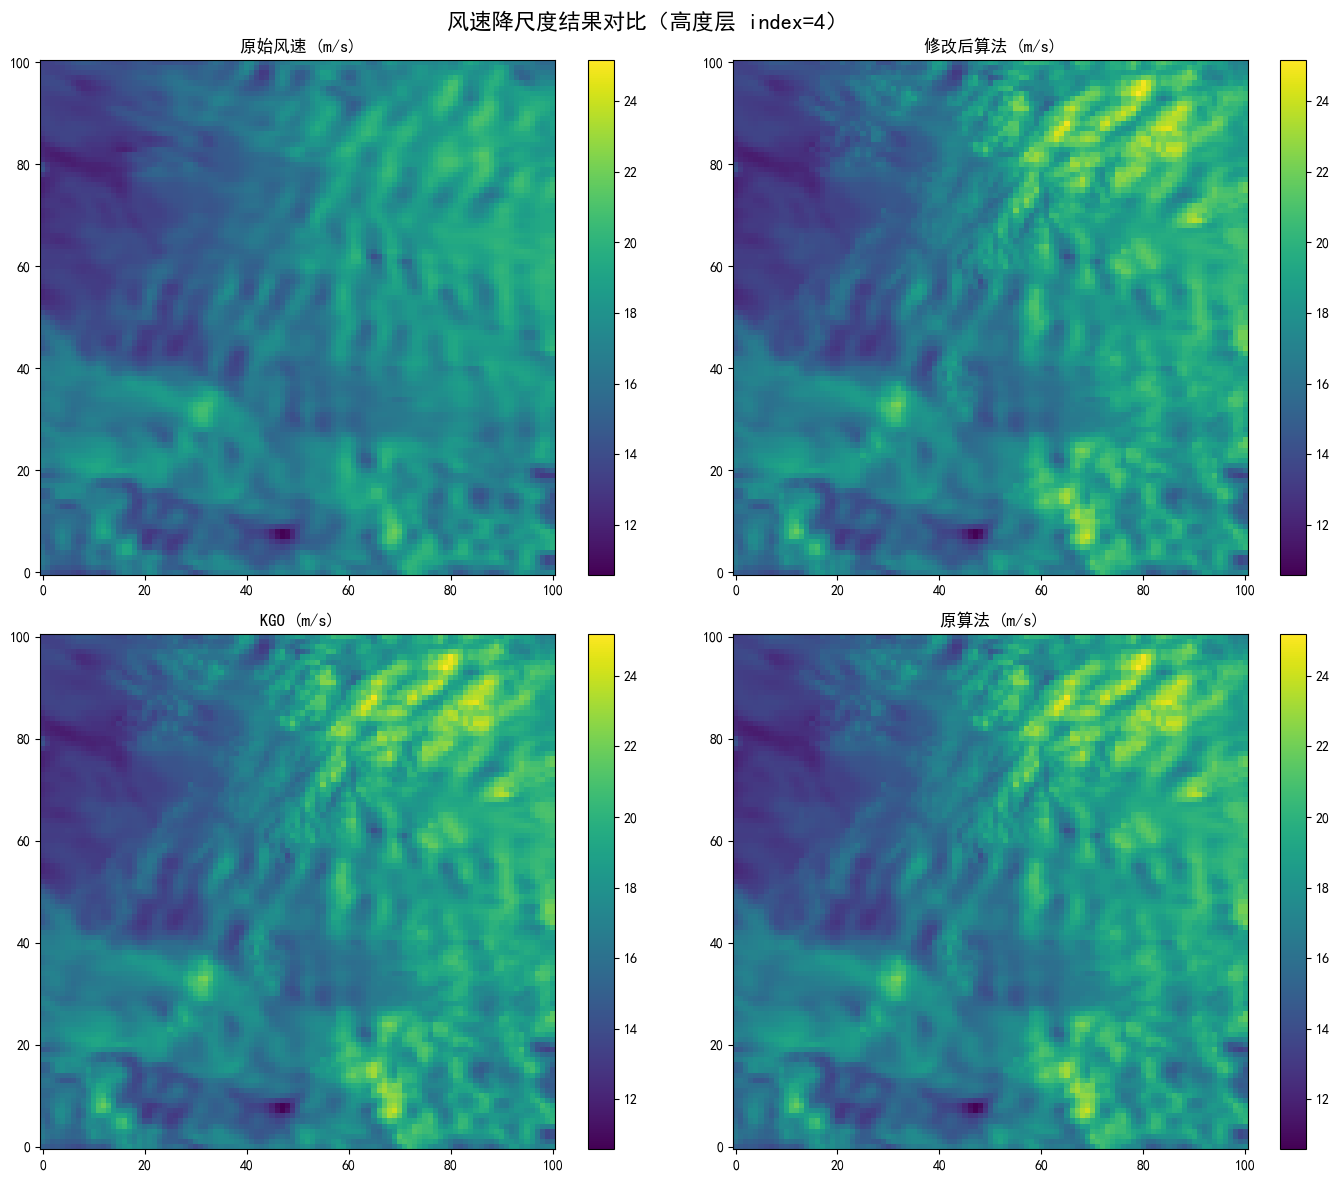

In [5]:
def _to_plot_ready(arr):
    data = to_spatial_values(arr)
    if data.ndim == 3:
        mid = data.shape[0] // 2
        return data[mid], mid
    return data, None


def plot_four_panel(wind_speed, modified, kgo, original, *, title: str):
    ws, mid = _to_plot_ready(wind_speed)
    mod, _ = _to_plot_ready(modified)
    kgo2d, _ = _to_plot_ready(kgo)
    orig, _ = _to_plot_ready(original)
    if mid is not None:
        mod, kgo2d, orig = mod, kgo2d, orig
        suffix = f"（高度层 index={mid}）"
    else:
        suffix = ""
    panels = [ws, mod, kgo2d, orig]
    vmin = min(p.min() for p in panels)
    vmax = max(p.max() for p in panels)
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f"{title}{suffix}", fontsize=16)
    labels = ["原始风速", "修改后算法", "KGO", "原算法"]
    for ax, arr, label in zip(axes.ravel(), panels, labels):
        im = ax.imshow(arr, cmap="viridis", origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(f"{label} (m/s)")
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()


plot_four_panel(
    wind_speed_da,
    modified_da,
    kgo_da,
    original_da,
    title="风速降尺度结果对比",
)

## CLI 验证

CLI 从 `cli_input/` 读取输入，结果写入 `cli_output/`。

示例脚本：`orographic_wind_downscaling/cli/dsc_wind_downscaling.py`

```powershell
python orographic_wind_downscaling/cli/dsc_wind_downscaling.py
```

=== CLI 对比 ===
[插件-修改后CLI] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000
[插件-原算法CLI] mean_abs=0.00000007, max_abs=0.00001383, rmse=0.00000035
[修改后CLI-原算法CLI] mean_abs=0.00000007, max_abs=0.00001383, rmse=0.00000035


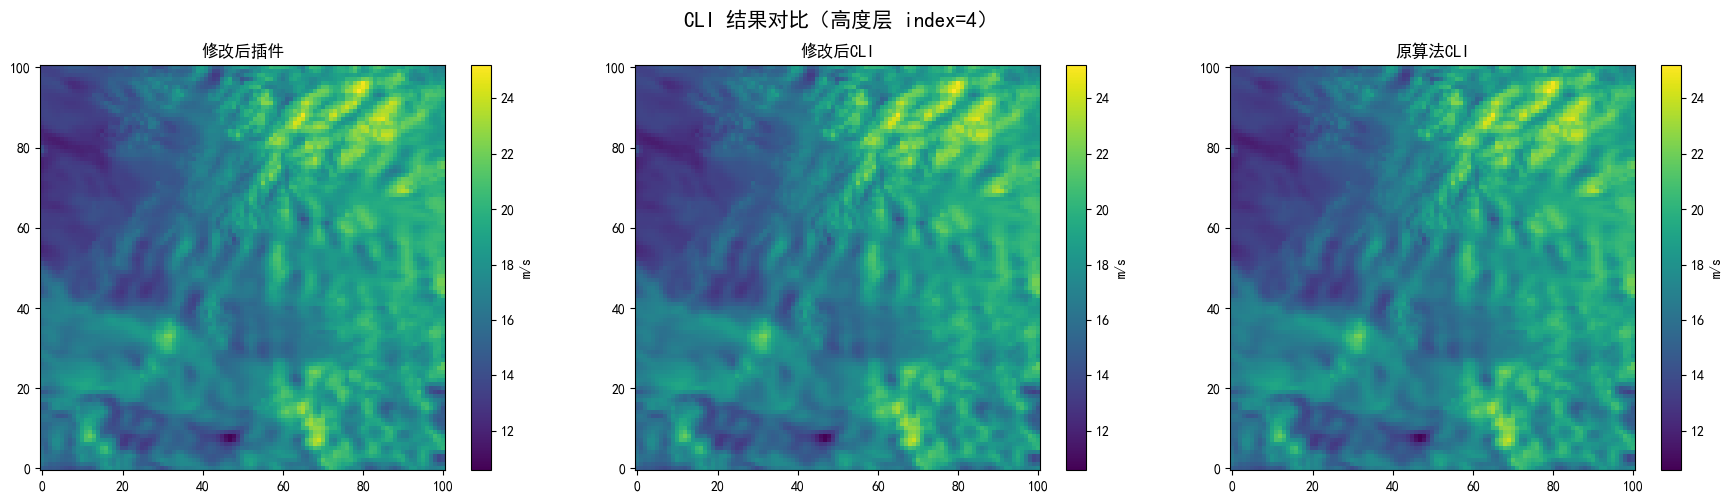

In [ ]:
cli_result = cli_process(
    str(CLI_INPUT_DIR / "input.nc"),
    str(CLI_INPUT_DIR / "sigma.nc"),
    str(CLI_INPUT_DIR / "highres_orog.nc"),
    str(CLI_INPUT_DIR / "standard_orog.nc"),
    str(CLI_INPUT_DIR / "a_over_s.nc"),
    MODEL_RESOLUTION,
    vegetative_roughness_path=str(CLI_INPUT_DIR / "veg.nc"),
)
original_cli_da = load_primary_dataarray(DATA_DIR / "original_cli_result.nc", "wind_speed")

print("=== CLI 对比 ===")
compare_stats(modified_da, cli_result, "插件-修改后CLI")
compare_stats(modified_da, original_cli_da, "插件-原算法CLI")
compare_stats(cli_result, original_cli_da, "修改后CLI-原算法CLI")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CLI 结果对比", fontsize=15)
mod2d, mid = _to_plot_ready(modified_da)
cli2d, _ = _to_plot_ready(cli_result)
orig_cli2d, _ = _to_plot_ready(original_cli_da)
if mid is not None:
    suffix = f"（高度层 index={mid}）"
else:
    suffix = ""
fig.suptitle(f"CLI 结果对比{suffix}", fontsize=15)
for ax, arr, label in zip(axes, [mod2d, cli2d, orig_cli2d], ["修改后插件", "修改后CLI", "原算法CLI"]):
    im = ax.imshow(arr, cmap="viridis", origin="lower")
    ax.set_title(label)
    plt.colorbar(im, ax=ax, fraction=0.046, label="m/s")
plt.tight_layout()
plt.show()